In [1]:
import pandas as pd
import torch
import cv2
import matplotlib.pyplot as plt
import sys
import os
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torch.utils.data import random_split
import torch.nn as nn
from collections import Counter
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Analiza Obrazu Cellulit
## Opis danych:
eksperyment: id osoby i 6 zdjęc pokazujacych jak dziala terapia jakaś sam nie wiem jaka

## Format zdjęć:
id_numer_klasa - 01_00_00
Gdzie:
id: id pacjenta i ma zakres 0 do 26
numer: numer pomiaru dla danego pacjenta i ma zakres od 0 do 6
klasa: stopień przewlekłości ma zakres od 0 do 3

Przyjęty sposób zapisu daje nam 156 zdjęć.


## Analiza pojedynczego obrazu

In [2]:
folder = "cellulit_data_without_scale_normalized"

file_name = f"{folder}/01_00_00.jpg"
img = cv2.imread(file_name)
img

array([[[151,   2,  70],
        [151,   2,  70],
        [153,   4,  72],
        ...,
        [143,   4,  48],
        [138,   0,  42],
        [141,   3,  45]],

       [[146,   0,  65],
        [149,   0,  68],
        [149,   0,  68],
        ...,
        [138,   0,  43],
        [135,   0,  40],
        [141,   2,  46]],

       [[150,   0,  68],
        [153,   2,  71],
        [149,   0,  66],
        ...,
        [138,   0,  45],
        [141,   1,  48],
        [141,   1,  48]],

       ...,

       [[ 88,   0,   0],
        [ 95,   4,   7],
        [ 90,   0,   2],
        ...,
        [104,   1,   8],
        [ 99,   0,   4],
        [ 97,   0,   4]],

       [[ 90,   0,   1],
        [ 91,   0,   4],
        [ 92,   1,   4],
        ...,
        [ 98,   0,   4],
        [ 95,   0,   4],
        [ 94,   0,   4]],

       [[ 98,   4,   9],
        [ 92,   0,   5],
        [ 91,   0,   3],
        ...,
        [103,   5,  11],
        [ 94,   0,   4],
        [ 88,   0,   0]]

In [3]:
img.shape

(240, 320, 3)

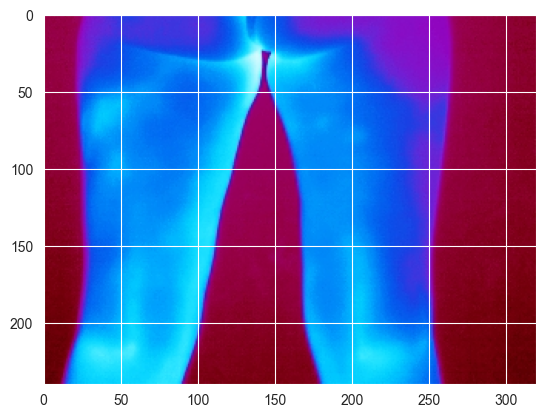

In [4]:
plt.imshow(img)

(array([73388., 16795., 17037., 10077., 15584., 32827.,  8757.,  6016.,
        12920., 36999.]),
 array([  0. ,  25.5,  51. ,  76.5, 102. , 127.5, 153. , 178.5, 204. ,
        229.5, 255. ]),
 <BarContainer object of 10 artists>)

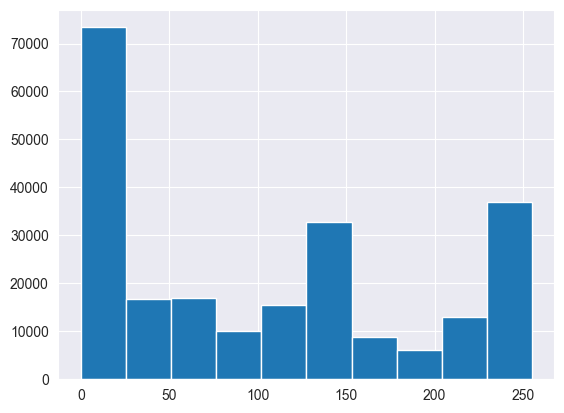

In [5]:
plt.hist(img.ravel())

inne zdjęcie

In [6]:
file_name = f"{folder}/02_00_01.jpg"
img = cv2.imread(file_name)
img.shape

(240, 320, 3)

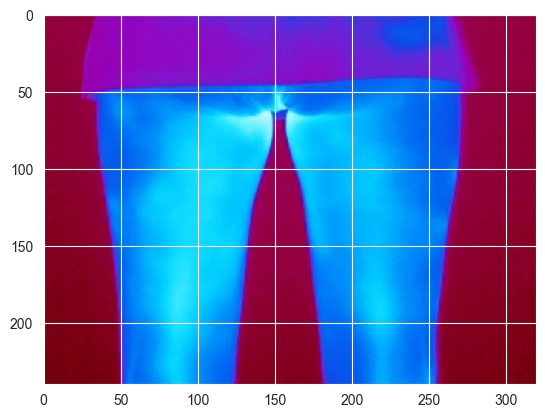

In [7]:
plt.imshow(img)

(array([73119., 17216., 14341.,  7695., 15013., 35723.,  6276., 11772.,
        12635., 36610.]),
 array([  0. ,  25.5,  51. ,  76.5, 102. , 127.5, 153. , 178.5, 204. ,
        229.5, 255. ]),
 <BarContainer object of 10 artists>)

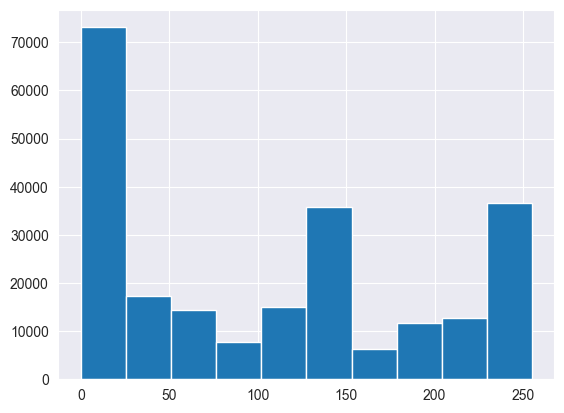

In [8]:
plt.hist(img.ravel())

## Analiza całego zbioru
Chce wczytać wszystkie te zdjęcia i zobaczyć jak bardzo nierówno te klasy są rozłożone względem siebie

In [9]:
classes = []
samples_per_classes = []
img_paths = []

for name in os.listdir(f"{folder}"):
    print(name)
    img_paths.append(f"{folder}/" + name)
    name = name.split('.')
    name = name[0].split('_')
    classes.append(int(name[2]))

counts = Counter(classes)
samples_per_classes = [counts[c] for c in sorted(counts.keys())]
print(classes)
print(len(classes))

01_00_00.jpg
01_02_00.jpg
01_04_00.jpg
01_06_00.jpg
01_10_00.jpg
02_00_01.jpg
02_01_01.jpg
02_02_02.jpg
02_04_02.jpg
02_06_02.jpg
02_10_01.jpg
03_00_02.jpg
03_01_01.jpg
03_02_01.jpg
03_04_00.jpg
03_06_02.jpg
03_10_02.jpg
04_00_01.jpg
04_01_01.jpg
04_02_01.jpg
04_04_01.jpg
04_06_01.jpg
04_10_01.jpg
05_00_03.jpg
05_01_01.jpg
05_02_02.jpg
05_04_02.jpg
05_06_02.jpg
05_10_01.jpg
06_00_03.jpg
06_01_01.jpg
06_02_01.jpg
06_04_02.jpg
06_06_01.jpg
06_10_00.jpg
07_00_03.jpg
07_01_02.jpg
07_02_02.jpg
07_04_02.jpg
07_06_01.jpg
07_10_01.jpg
08_00_02.jpg
08_01_01.jpg
08_02_01.jpg
08_04_01.jpg
08_06_01.jpg
08_10_01.jpg
09_00_02.jpg
09_01_02.jpg
09_02_03.jpg
09_03_02.jpg
09_06_02.jpg
09_10_02.jpg
10_00_03.jpg
10_01_01.jpg
10_02_02.jpg
10_04_02.jpg
10_06_01.jpg
10_10_00.jpg
11_00_02.jpg
11_01_01.jpg
11_02_01.jpg
11_04_00.jpg
12_00_01.jpg
12_01_01.jpg
12_02_01.jpg
12_04_01.jpg
12_06_02.jpg
12_10_01.jpg
13_00_01.jpg
13_01_01.jpg
13_02_01.jpg
13_04_03.jpg
13_06_01.jpg
13_10_03.jpg
14_00_02.jpg
14_01_02.jpg

(array([23.,  0.,  0., 72.,  0.,  0., 50.,  0.,  0., 12.]),
 array([0. , 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.1, 2.4, 2.7, 3. ]),
 <BarContainer object of 10 artists>)

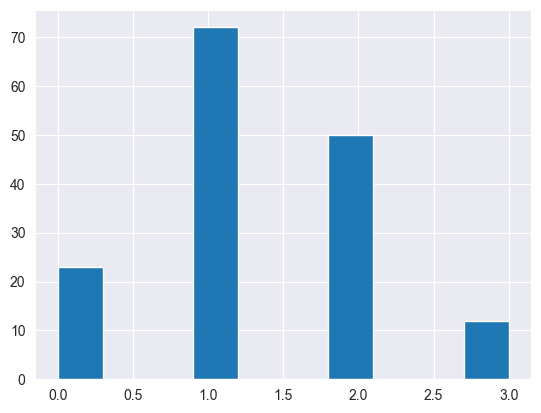

In [10]:
plt.hist(classes)

Widać dominację klasy 01 przypadki braku cellulitu to zaledwie 20 przypadków co jest raczej małą ilością i trzeba będzie myśleć może nad augmentacją tylko pytanie jaką obracanie czy tego typu rzeczy raczej nie mają sensu.

## Opakowanie zbioru danych w dataloadery

In [34]:
class CelluliteDataset(Dataset):
    def __init__(self, image_path, label, transform=None):
        self.image_path = image_path
        self.label = label
        self.transform = transform

    def __len__(self):
        return len(self.image_path)

    def __getitem__(self, idx):
        image = cv2.imread(self.image_path[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        label = self.label[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

img_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((240, 320)),
    transforms.ToTensor(),
    ])

In [35]:
# dataset

dataset = CelluliteDataset(img_paths, classes, img_transform)
train_size = int(0.8 * len(dataset))
test_size = int(len(dataset) - train_size)


train_set, test_set = random_split(dataset, [train_size, test_size])

# dataloader

train_loader = DataLoader(
    dataset=train_set,
    batch_size=16,
    shuffle=True,
    num_workers=0,
    pin_memory=True
    )

test_loader = DataLoader(
    dataset=test_set,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    pin_memory=True
    )

## Pierwsza sieć neuronowa
Skorzystam z wag wytrenowanego wcześniej modelu ConvNeXt Tiny i podmienię głowę.

In [36]:
model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False

in_features = model.classifier[2].in_features
model.classifier[2] = nn.Linear(in_features, 4)

for param in model.classifier[2].parameters():
    param.requires_grad = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

weights = [sum(samples_per_classes) / c for c in samples_per_classes]
class_weights = torch.FloatTensor(weights).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.classifier[2].parameters(), lr=0.001)

In [37]:
EPOCHS = 200
class_names = ['00', '01', '02', '03']

patience = 20
best_val_loss = float('inf')
epochs_no_improve = 0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_acc = 100 * correct_train / total_train
    avg_train_loss = running_loss / len(train_loader)

    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_acc = 100 * correct_val / total_val
    avg_val_loss = val_loss / len(test_loader)

    print(f"Epoka [{epoch+1}/{EPOCHS}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0

        torch.save(model.state_dict(), 'model.pth')
    else:
        epochs_no_improve += 1
        print(f"Brak poprawy Val Loss od {epochs_no_improve} epok(i).")

        if epochs_no_improve >= patience:
            print(f"\n Przerwano trening w epoce {epoch+1}, aby zapobiec przeuczeniu modelu!")
            break

print("Wczytywanie najlepszych wag do ostatecznej ewaluacji...")
model.load_state_dict(torch.load('model.pth'))

Epoka [1/200] | Train Loss: 1.4608 | Val Loss: 1.4057 | Val Acc: 21.43%
Epoka [2/200] | Train Loss: 1.3072 | Val Loss: 1.4827 | Val Acc: 32.14%
Brak poprawy Val Loss od 1 epok(i).
Epoka [3/200] | Train Loss: 1.1633 | Val Loss: 1.2196 | Val Acc: 57.14%
Epoka [4/200] | Train Loss: 1.0831 | Val Loss: 1.1564 | Val Acc: 60.71%
Epoka [5/200] | Train Loss: 1.0347 | Val Loss: 1.1343 | Val Acc: 50.00%
Epoka [6/200] | Train Loss: 1.0038 | Val Loss: 1.1463 | Val Acc: 60.71%
Brak poprawy Val Loss od 1 epok(i).
Epoka [7/200] | Train Loss: 0.9403 | Val Loss: 1.0516 | Val Acc: 60.71%
Epoka [8/200] | Train Loss: 0.9226 | Val Loss: 1.0576 | Val Acc: 57.14%
Brak poprawy Val Loss od 1 epok(i).
Epoka [9/200] | Train Loss: 0.8771 | Val Loss: 1.0358 | Val Acc: 57.14%
Epoka [10/200] | Train Loss: 0.8086 | Val Loss: 1.0282 | Val Acc: 57.14%
Epoka [11/200] | Train Loss: 0.7813 | Val Loss: 1.0689 | Val Acc: 60.71%
Brak poprawy Val Loss od 1 epok(i).
Epoka [12/200] | Train Loss: 0.7196 | Val Loss: 1.0266 | Val A

<All keys matched successfully>

In [38]:
print("\nRozpoczynamy ewaluację na zbiorze testowym...")
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


Rozpoczynamy ewaluację na zbiorze testowym...


              precision    recall  f1-score   support

          00       0.57      0.57      0.57         7
          01       0.62      0.71      0.67        14
          02       0.33      0.17      0.22         6
          03       0.00      0.00      0.00         1

    accuracy                           0.54        28
   macro avg       0.38      0.36      0.37        28
weighted avg       0.53      0.54      0.52        28



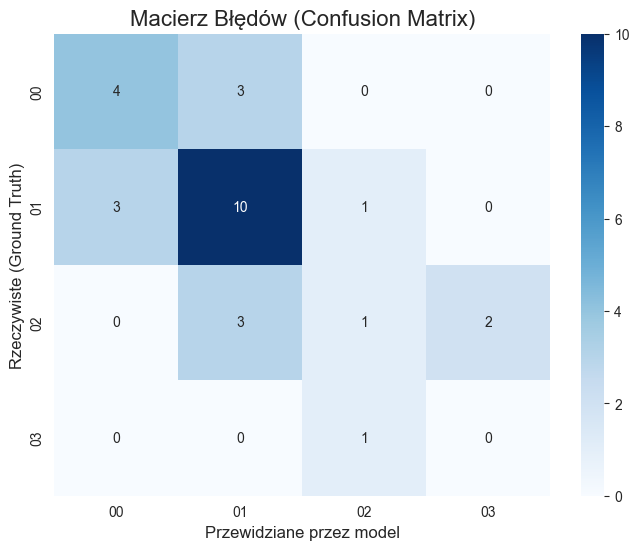

In [39]:
raport = classification_report(all_labels, all_preds, target_names=class_names)
print(raport)

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title('Macierz Błędów (Confusion Matrix)', fontsize=16)
plt.xlabel('Przewidziane przez model', fontsize=12)
plt.ylabel('Rzeczywiste (Ground Truth)', fontsize=12)
plt.show()

# Analiza dla danych ze skalą